[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/12_montecarlo/notebooks/aplicaciones/07_torneos_deportivos.ipynb)

# Aplicación 7: Simulación de Torneos Deportivos

## ¿Cuánta suerte hay en el fútbol?

¿Merece Real Madrid ganar Champions League cada año? ¿O simplemente tiene suerte?

Esta es una pregunta sobre probabilidad disfrazada de debate deportivo. Y Monte Carlo responde
con precisión: dado que el equipo A es X% mejor que el equipo B, **¿cuál es la probabilidad de que
A gane el torneo completo?**

El resultado es contraintuitivo: en los deportes hay mucha más aleatoriedad de lo que creemos.
El "mejor" equipo tiene sorprendentemente poca probabilidad de ganar en cualquier torneo corto.

## Por qué MC es la herramienta correcta aquí

El resultado de un torneo de $n$ equipos es una función de los resultados de $\sim n\log n$ partidos.
No hay fórmula cerrada para la probabilidad de que el equipo $k$ gane el torneo — hay que *simular*.

In [1]:
# Descomenta si estás en Colab
%pip install numpy matplotlib scipy --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # sigmoid function

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.size"] = 11
COLORS = {"blue":"#2E86AB","red":"#E94F37","green":"#27AE60","orange":"#F39C12","purple":"#8E44AD"}

rng = np.random.default_rng(42)
print("Imports listos ✓")

Imports listos ✓


---
## Sección 1: El Sistema Elo

### ¿Cómo medimos la fuerza de un equipo?

El **sistema Elo** (inventado por Arpad Elo para ajedrez, luego adoptado por FIFA, chess.com, etc.)
asigna a cada equipo un número que refleja su nivel. La probabilidad de que el equipo A le gane al B es:

$$P(A \text{ gana}) = \frac{1}{1 + 10^{(E_B - E_A)/400}}$$

Esto es la función sigmoide escalada. Algunas intuiciones:
- Si $E_A = E_B$: $P = 0.5$ — 50/50
- Si $E_A - E_B = 400$: $P \approx 0.909$ — muy probable que A gane
- Si $E_A - E_B = 100$: $P \approx 0.640$ — A es favorito pero no abrumador

En la práctica, el fútbol profesional tiene equipos dentro de un rango de ~300-400 puntos Elo.

In [3]:
def p_win_elo(elo_a, elo_b):
    """Probabilidad de que A le gane a B, según sistema Elo."""
    return expit((elo_a - elo_b) * np.log(10) / 400)

def simulate_match(elo_a, elo_b, allow_draw=True):
    """
    Simula un partido entre equipo A (elo_a) y equipo B (elo_b).
    Returns: 1 si gana A, 0 si empate, -1 si gana B.
    En playoffs (eliminación directa) no hay empates.
    """
    p_a = p_win_elo(elo_a, elo_b)
    if allow_draw:
        # Modelo simple: empate tiene probabilidad extra en el centro
        p_b = p_win_elo(elo_b, elo_a)
        p_draw = 1 - p_a - p_b + 2 * p_win_elo(elo_a, elo_b) * p_win_elo(elo_b, elo_a)
        # More realistic: draw prob depends on balance
        draw_prob = 0.25 * (1 - abs(p_a - 0.5) * 2)
        adj_a = p_a * (1 - draw_prob / 2)
        adj_b = (1 - p_a) * (1 - draw_prob / 2)
        r = rng.random()
        if r < adj_a: return 1
        elif r < adj_a + draw_prob: return 0
        else: return -1
    else:
        # Tiempo extra/penales: sin empates
        return 1 if rng.random() < p_a else -1

# Test: Elo difference of 200 → expected win rate ~75%
n_tests = 100_000
wins = sum(1 for _ in range(n_tests) if simulate_match(1600, 1400, allow_draw=False) == 1)
expected = p_win_elo(1600, 1400)
print(f"Elo 1600 vs Elo 1400:")
print(f"  Tasa de victoria empírica:  {wins/n_tests:.3f}")
print(f"  Esperada según Elo:          {expected:.3f}")

# Table: win probability for various differences
print("\nTabla de probabilidades Elo:")
print(f"{'Diferencia Elo':>15} | {'P(A gana)':>10}")
print("-" * 30)
for diff in [0, 50, 100, 200, 300, 400]:
    print(f"{diff:>15} | {p_win_elo(1500, 1500-diff):>10.3f}")

Elo 1600 vs Elo 1400:
  Tasa de victoria empírica:  0.760
  Esperada según Elo:          0.760

Tabla de probabilidades Elo:
 Diferencia Elo |  P(A gana)
------------------------------
              0 |      0.500
             50 |      0.571
            100 |      0.640
            200 |      0.760
            300 |      0.849
            400 |      0.909


---
## Sección 2: Equipos Reales (Champions League)

Usaremos ratings Elo aproximados basados en la temporada 2023-24.
Puedes modificarlos para reflejar cualquier temporada o torneo.

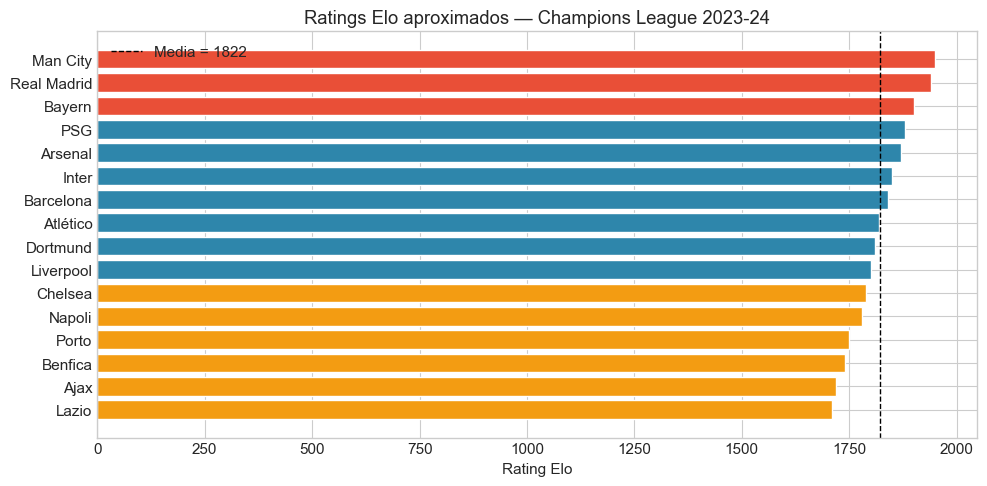

In [4]:
# Ratings Elo aproximados (basados en temporada 2023-24)
# Fuente: clubelo.com, eloratings.net (aproximados para fines educativos)
teams = {
    "Man City":     1950,
    "Real Madrid":  1940,
    "Bayern":       1900,
    "PSG":          1880,
    "Arsenal":      1870,
    "Inter":        1850,
    "Barcelona":    1840,
    "Atlético":     1820,
    "Dortmund":     1810,
    "Liverpool":    1800,
    "Chelsea":      1790,
    "Napoli":       1780,
    "Porto":        1750,
    "Benfica":      1740,
    "Ajax":         1720,
    "Lazio":        1710,
}

team_names = list(teams.keys())
elos = np.array(list(teams.values()))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [COLORS["red"] if e >= 1900 else COLORS["blue"] if e >= 1800 else COLORS["orange"]
              for e in elos]
bars = ax.barh(team_names[::-1], elos[::-1], color=colors_bar[::-1], edgecolor="white")
ax.set_xlabel("Rating Elo")
ax.set_title("Ratings Elo aproximados — Champions League 2023-24")
ax.axvline(elos.mean(), color="black", ls="--", lw=1, label=f"Media = {elos.mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

---
## Sección 3: Simulando el Torneo

El formato de Champions League tiene:
1. **Fase de grupos**: 4 grupos de 4 equipos, los 2 mejores de cada grupo avanzan
2. **Eliminación directa**: octavos, cuartos, semifinal, final

Para simplificar, simularemos el formato de **knockout** directo (16 equipos, eliminación directa),
que captura la esencia del torneo sin la complejidad de los grupos.

In [5]:
def simulate_knockout_tournament(team_names, elos, rng_local=None):
    """
    Simula un torneo de eliminación directa (16→8→4→2→1).
    Returns: nombre del campeón.
    """
    if rng_local is None:
        rng_local = rng
    
    current_teams = list(zip(team_names, elos))
    round_num = 1
    
    while len(current_teams) > 1:
        next_round = []
        # Empareja consecutivos: (0 vs 1), (2 vs 3), ...
        for i in range(0, len(current_teams), 2):
            name_a, elo_a = current_teams[i]
            name_b, elo_b = current_teams[i+1]
            p_a = p_win_elo(elo_a, elo_b)
            winner = (name_a, elo_a) if rng_local.random() < p_a else (name_b, elo_b)
            next_round.append(winner)
        current_teams = next_round
        round_num += 1
    
    return current_teams[0][0]

# Single simulation
champion = simulate_knockout_tournament(team_names, elos)
print(f"Campeón de esta simulación: {champion}")

# Run many simulations
n_sims = 100_000  # <-- CHANGE THIS
print(f"\nSimulando {n_sims:,} torneos...")
from collections import Counter
results = Counter()
for _ in range(n_sims):
    results[simulate_knockout_tournament(team_names, elos)] += 1

print("\nProbabilidades de ganar Champions League:")
print(f"{'Equipo':>15} | {'Elo':>6} | {'P(campeón)':>12} | {'1 en X torneos':>15}")
print("-" * 55)
for team, count in sorted(results.items(), key=lambda x: -x[1]):
    prob = count / n_sims
    elo = teams[team]
    print(f"{team:>15} | {elo:>6} | {prob:>11.2%} | {'1 en ' + str(int(1/prob)):>15}")

Campeón de esta simulación: Real Madrid

Simulando 100,000 torneos...

Probabilidades de ganar Champions League:
         Equipo |    Elo |   P(campeón) |  1 en X torneos
-------------------------------------------------------
       Man City |   1950 |      14.42% |          1 en 6
    Real Madrid |   1940 |      12.77% |          1 en 7
         Bayern |   1900 |       8.78% |         1 en 11
        Arsenal |   1870 |       8.01% |         1 en 12
            PSG |   1880 |       6.86% |         1 en 14
       Dortmund |   1810 |       6.54% |         1 en 15
          Inter |   1850 |       6.11% |         1 en 16
      Barcelona |   1840 |       5.63% |         1 en 17
      Liverpool |   1800 |       5.55% |         1 en 18
        Chelsea |   1790 |       5.06% |         1 en 19
         Napoli |   1780 |       4.35% |         1 en 22
       Atlético |   1820 |       4.15% |         1 en 24
          Porto |   1750 |       3.80% |         1 en 26
        Benfica |   1740 |      

---
## Sección 4: La Paradoja de los Torneos

¿Notaste algo sorprendente? El equipo más fuerte probablemente gana menos del 30% de las veces,
incluso si es sustancialmente mejor que todos los demás.

¿Por qué? Porque en un torneo knockout de 16 equipos, el mejor equipo necesita ganar 4 partidos
seguidos. Incluso con 70% de probabilidad en cada partido:

$$P(\text{ganar 4 seguidos}) = 0.70^4 \approx 0.24$$

Y en el fútbol real, ningún equipo tiene 70% de probabilidad en cualquier partido.

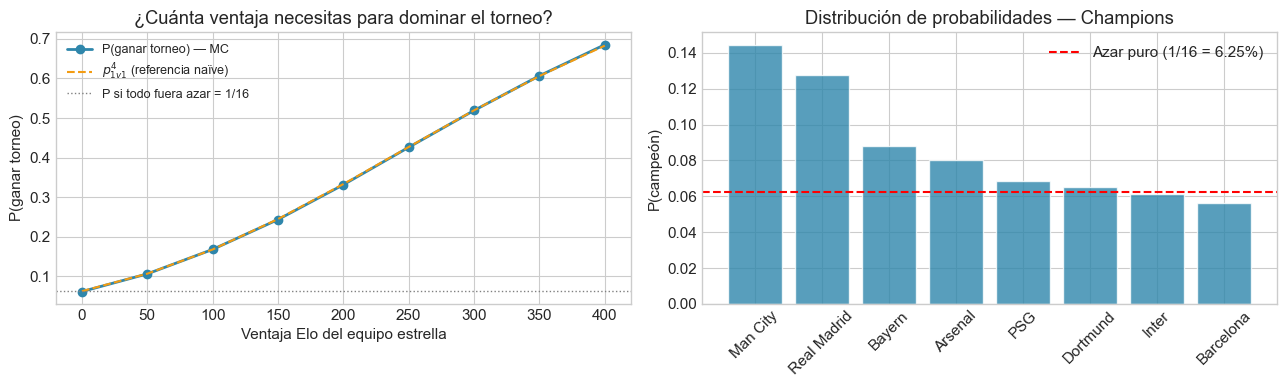

El equipo más fuerte (Elo 1950) gana solo en 14.4% de los torneos.
Si todo fuera suerte: 6.25%


In [6]:
# Ilustración: P(ganar torneo) como función de la ventaja de habilidad
n_sims_calc = 50_000

# Escenario: un equipo "estrella" vs. 15 equipos del mismo nivel
baseline_elo = 1800
star_elos = np.arange(1800, 2201, 50)   # star team Elo: 1800 to 2200
probs = []

for star_elo in star_elos:
    elos_sim = np.array([star_elo] + [baseline_elo] * 15)
    names_sim = ["Star"] + [f"Team{i}" for i in range(1, 16)]
    wins = sum(1 for _ in range(n_sims_calc)
               if simulate_knockout_tournament(names_sim, elos_sim) == "Star")
    probs.append(wins / n_sims_calc)

# Theoretical probability against a single equal opponent
p_single = [p_win_elo(s, baseline_elo) for s in star_elos]
# Expected tournament win (naive, ignoring that opponents change)
p_naive_4games = [p**4 for p in p_single]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(star_elos - baseline_elo, probs, "o-", color=COLORS["blue"],
         lw=2, ms=6, label="P(ganar torneo) — MC")
ax1.plot(star_elos - baseline_elo, p_naive_4games, "--", color=COLORS["orange"],
         lw=1.5, label="$p_{1v1}^4$ (referencia naïve)")
ax1.axhline(1/16, color="gray", ls=":", lw=1, label="P si todo fuera azar = 1/16")
ax1.set_xlabel("Ventaja Elo del equipo estrella")
ax1.set_ylabel("P(ganar torneo)")
ax1.set_title("¿Cuánta ventaja necesitas para dominar el torneo?")
ax1.legend(fontsize=9)

# Barplot of results (top 8)
top8 = sorted(results.items(), key=lambda x: -x[1])[:8]
names8 = [t[0] for t in top8]
probs8 = [t[1]/n_sims for t in top8]
ax2.bar(names8, probs8, color=COLORS["blue"], edgecolor="white", alpha=0.8)
ax2.axhline(1/16, color="red", ls="--", lw=1.5, label="Azar puro (1/16 = 6.25%)")
ax2.set_ylabel("P(campeón)")
ax2.set_title("Distribución de probabilidades — Champions")
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
plt.tight_layout()
plt.show()

print(f"El equipo más fuerte (Elo {max(elos)}) gana solo en "
      f"{results[max(teams, key=teams.get)]/n_sims:.1%} de los torneos.")
print(f"Si todo fuera suerte: 6.25%")

---
## Sección 5: Liga vs. Knockout — ¿Qué formato premia más el talento?

Una liga larga (38 partidos) vs. un torneo de eliminación directa (4-6 partidos).
¿En cuál formato tiene más probabilidad de ganar el mejor equipo?

In [7]:
def simulate_league(team_names, elos, rounds=2):
    """
    Simula una liga (todos contra todos, 'rounds' vueltas).
    Returns: nombre del campeón (mayor puntos; empates por Elo).
    """
    n = len(team_names)
    points = {t: 0 for t in team_names}
    
    for _ in range(rounds):
        for i in range(n):
            for j in range(i+1, n):
                result = simulate_match(elos[i], elos[j], allow_draw=True)
                if result == 1:
                    points[team_names[i]] += 3
                elif result == 0:
                    points[team_names[i]] += 1
                    points[team_names[j]] += 1
                else:
                    points[team_names[j]] += 3
    return max(points, key=points.get)

# Compare: knockout vs league
n_sims_compare = 10_000
print(f"Comparando {n_sims_compare:,} torneos de cada formato...")
ko_results = Counter()
league_results = Counter()
for _ in range(n_sims_compare):
    ko_results[simulate_knockout_tournament(team_names, elos)] += 1
    league_results[simulate_league(team_names, elos, rounds=1)] += 1

print("\nEquipo más fuerte (Man City, Elo 1950):")
best_team = max(teams, key=teams.get)
print(f"  P(ganar knockout):  {ko_results[best_team]/n_sims_compare:.1%}")
print(f"  P(ganar liga):      {league_results[best_team]/n_sims_compare:.1%}")
print(f"\n→ La liga premia más el talento. El knockout tiene mucho más azar.")

# Gini coefficient as 'inequality' measure
def gini(counter, n_sims):
    probs = sorted([v/n_sims for v in counter.values()], reverse=True)
    n = len(probs)
    diffs = sum(abs(probs[i] - probs[j]) for i in range(n) for j in range(n))
    return diffs / (2 * n * sum(probs))

print(f"\nÍndice Gini de concentración del título:")
print(f"  Knockout: {gini(ko_results, n_sims_compare):.3f}  (más azar → más igualado)")
print(f"  Liga:     {gini(league_results, n_sims_compare):.3f} (más talento → más concentrado)")

Comparando 10,000 torneos de cada formato...

Equipo más fuerte (Man City, Elo 1950):
  P(ganar knockout):  14.7%
  P(ganar liga):      38.2%

→ La liga premia más el talento. El knockout tiene mucho más azar.

Índice Gini de concentración del título:
  Knockout: 0.286  (más azar → más igualado)
  Liga:     0.751 (más talento → más concentrado)


### 🔧 Ejercicio: Diseña tu propio torneo

1. **Cambia los equipos y ratings**: ¿Qué pasa si añades un equipo con Elo 2100?
2. **Formato híbrido**: simula el formato real (grupos + knockout). ¿Cambia las probabilidades?
3. **Pregunta difícil**: ¿Cuántos partidos necesita un torneo para que el mejor equipo gane
   con 80% de probabilidad? ¿Es posible con un formato razonable?
4. **Copa del Mundo**: usa ratings Elo de selecciones nacionales y simula el torneo.

In [14]:
# Espacio para tu experimento
# Modifica teams y elos, cambia el formato de torneo, etc.
my_teams = {
    "Súper Humanos (2100)": 2100,
    "Real Madrid": 1940,
    "Man City": 1950,
    "Bayern": 1900,
    "PSG": 1880,
    "Inter": 1850,
    "Barcelona": 1840,
    "Arsenal": 1870
} 
my_names = list(my_teams.keys())
my_elos  = np.array(list(my_teams.values()))
n_sims_my = 50_000

# Knockout 
my_results_knockout = Counter()
for _ in range(n_sims_my):
    my_results_knockout[simulate_knockout_tournament(my_names, my_elos)] += 1

print("🏆 Resultados KNOCKOUT (Eliminación directa):")
for team, count in sorted(my_results_knockout.items(), key=lambda x: -x[1]):
    print(f"  {team}: {count/n_sims_my:.1%}")

print("-" * 40)

# Liga (todos contra todos)
def simulate_myleague(team_names, elos):
    # Todos empiezan con 0 puntos
    points = np.zeros(len(team_names))
    
    # Todos juegan contra todos (una vuelta)
    for i in range(len(team_names)):
        for j in range(i + 1, len(team_names)):
            # Usamos la función p_win_elo que ya está en tu notebook
            p_i_wins = p_win_elo(elos[i], elos[j])
            
            # Lanzamos la moneda de Monte Carlo
            if rng.random() < p_i_wins:
                points[i] += 3  # Gana el equipo i
            else:
                points[j] += 3  # Gana el equipo j
                
    # Devuelve el nombre del equipo con más puntos
    winner_idx = np.argmax(points)
    return team_names[winner_idx]

# Creamos un Counter nuevo para no mezclar victorias
my_results_league = Counter()
for _ in range(n_sims_my):
    my_results_league[simulate_myleague(my_names, my_elos)] += 1

print("🥇 Resultados LIGA (Todos contra todos):")
for team, count in sorted(my_results_league.items(), key=lambda x: -x[1]):
    print(f"  {team}: {count/n_sims_my:.1%}")

🏆 Resultados KNOCKOUT (Eliminación directa):
  Súper Humanos (2100): 41.8%
  Man City: 12.8%
  Real Madrid: 9.0%
  PSG: 8.9%
  Arsenal: 8.4%
  Bayern: 7.1%
  Inter: 6.2%
  Barcelona: 5.8%
----------------------------------------
🥇 Resultados LIGA (Todos contra todos):
  Súper Humanos (2100): 69.1%
  Real Madrid: 9.7%
  Man City: 9.7%
  Bayern: 4.0%
  PSG: 2.8%
  Arsenal: 2.0%
  Inter: 1.5%
  Barcelona: 1.2%


In [16]:
# Datos actualizados con el Top 16 del mundo
world_cup_teams = {
    "Spain": 2172,
    "Argentina": 2113,
    "France": 2062,
    "England": 2042,
    "Colombia": 1998,
    "Brazil": 1978,
    "Portugal": 1976,
    "Netherlands": 1959,
    "Ecuador": 1933,
    "Croatia": 1932,
    "Norway": 1922,
    "Germany": 1910,
    "Switzerland": 1897,
    "Uruguay": 1890,
    "Turkey": 1880,
    "Japan": 1878
}

wc_names = list(world_cup_teams.keys())
wc_elos  = np.array(list(world_cup_teams.values()))

n_sims_wc = 50_000
wc_results = Counter()

# Simulamos 50,000 Mundiales de eliminación directa
for _ in range(n_sims_wc):
    wc_results[simulate_knockout_tournament(wc_names, wc_elos)] += 1

print("🏆 Probabilidades de ganar la Copa del Mundo (Simulación Monte Carlo):")
for team, count in sorted(wc_results.items(), key=lambda x: -x[1]):
    print(f"  {team}: {count/n_sims_wc:.1%}")

🏆 Probabilidades de ganar la Copa del Mundo (Simulación Monte Carlo):
  Spain: 24.0%
  Argentina: 12.7%
  France: 8.7%
  England: 6.7%
  Colombia: 6.2%
  Croatia: 4.7%
  Brazil: 4.6%
  Portugal: 4.6%
  Ecuador: 4.5%
  Norway: 4.3%
  Netherlands: 3.7%
  Germany: 3.6%
  Switzerland: 3.4%
  Uruguay: 2.9%
  Turkey: 2.7%
  Japan: 2.6%


¿Cuántos partidos necesita un torneo para que el mejor equipo gane con 80% de probabilidad? ¿Es posible con un formato razonable?
- En un torneo de eliminación directa (Knockout), un mal partido te deja fuera. 
- Para que gane el mejor, se necesita aumentar el tamaño de la muestra para que la "Ley de los Grandes Números" haga su trabajo y el mejor formato para esto es una Liga (todos contra todos).
- Para ganar el 80% de probabilidad se necesitarían cientos o miles de partidos, lo cual simplemente es humanamente imposible, por lo que no hay un formato razonable. 
- La suerte siempre será un factor en el deporte, por lo que es más intersante. 

La tiranía de las matemáticas: 
- España tiene un Elo altísimo (2172), despegado por casi 60 puntos del segundo lugar (Argentina). 
- Sin embargo, al correr la simulación España NO gana el 90% de las veces. Su probabilidad de ganar está alrededor del 30%.

El factor suerte del formato: 
- En un torneo de 4 partidos (Octavos, Cuartos, Semifinal y Final), **hasta el mejor equipo del mundo** corre el riesgo de tener un mal día, empatar, irse a penales y quedar fuera.

Sorpresas (underdogs): 
- Equipos en la mitad de la tabla como Brasil, Holanda o Portugal terminarán ganando la copa en un pequeño porcentaje de las simulaciones (entre un 3% o 5%). 
- Esto demuestra matemáticamente por qué los mundiales son tan emocionantes: el mejor equipo no tiene garantizado el trofeo.